<a href="https://colab.research.google.com/github/O-suke12/ObjectDetection/blob/main/YOLOv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import torch.nn as nn
import torch
import pandas as pd
from PIL import Image
import os

# **Reference**

Original papaer: https://arxiv.org/pdf/1506.02640.pdf

Datasets; https://www.kaggle.com/datasets/734b7bcb7ef13a045cbdd007a3c19874c2586ed0b02b4afc86126e89d00af8d2

Overall: https://youtu.be/n9_XyCGr-MI

Architecture: https://youtu.be/zgbPj4lSc58

Batch norm: https://www.youtube.com/watch?v=yXOMHOpbon8


# **Datasets**

Download kaggle.json

In [6]:
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [7]:
! kaggle datasets download -d aladdinpersson/pascalvoc-yolo

100% 4.29G/4.31G [00:36<00:00, 124MB/s]
100% 4.31G/4.31G [00:36<00:00, 126MB/s]


In [8]:
! unzip pascalvoc-yolo

Streaming output truncated to the last 5000 lines.
  inflating: labels/2009_004289.txt  
  inflating: labels/2009_004290.txt  
  inflating: labels/2009_004291.txt  
  inflating: labels/2009_004295.txt  
  inflating: labels/2009_004298.txt  
  inflating: labels/2009_004300.txt  
  inflating: labels/2009_004301.txt  
  inflating: labels/2009_004303.txt  
  inflating: labels/2009_004307.txt  
  inflating: labels/2009_004308.txt  
  inflating: labels/2009_004309.txt  
  inflating: labels/2009_004312.txt  
  inflating: labels/2009_004315.txt  
  inflating: labels/2009_004316.txt  
  inflating: labels/2009_004317.txt  
  inflating: labels/2009_004319.txt  
  inflating: labels/2009_004322.txt  
  inflating: labels/2009_004323.txt  
  inflating: labels/2009_004324.txt  
  inflating: labels/2009_004327.txt  
  inflating: labels/2009_004328.txt  
  inflating: labels/2009_004329.txt  
  inflating: labels/2009_004332.txt  
  inflating: labels/2009_004334.txt  
  inflating: labels/2009_004336.txt  

In [118]:
label

['11',
 '0.34419263456090654',
 '0.611',
 '0.4164305949008499',
 '0.262',
 '14',
 '0.509915014164306',
 '0.51',
 '0.9745042492917847',
 '0.972']

<ipython-input-126-23f4ec624f2a>:32: DeprecationWarning: an integer is required (got type float).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  bbox = torch.tensor(bbox, dtype=torch.int)
<ipython-input-126-23f4ec624f2a>:33: DeprecationWarning: an integer is required (got type float).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  bbox1 = torch.tensor(bbox1, dtype=torch.int)


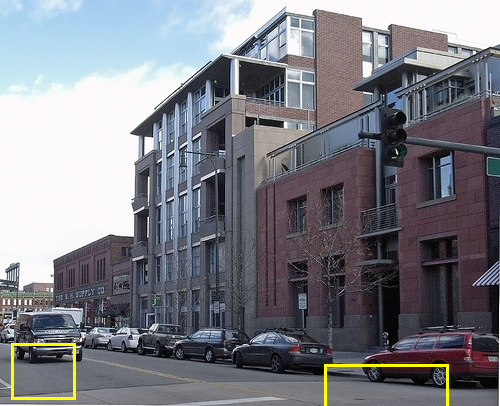

In [126]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

df_train = pd.read_csv("/content/train.csv")
df_test = pd.read_csv("/content/test.csv")
df_example = pd.read_csv("/content/8examples.csv")

label_ex = open("/content/labels/000004.txt", "r")
label = label_ex.read().split()

center_x = float(label[1])*448 
center_y = float(label[2])*448
width = float(label[3])*448
height = float(label[4])*448
x_min = center_x-width/2
y_min = center_y-height/2
x_max = center_x+width/2
y_max = center_y+height/2
center_x = float(label[6])*448 
center_y = float(label[7])*448
width = float(label[8])*448
height = float(label[9])*448
x2_min = center_x-width/2
y2_min = center_y-height/2
x2_max = center_x+width/2
y2_max = center_y+height/2

img = read_image('/content/images/000004.jpg')
bbox = [x_min, y_min, x_max, y_max]
bbox1 = [x2_min, y2_min, x2_max, y2_max]
bbox = torch.tensor(bbox, dtype=torch.int)
bbox1 = torch.tensor(bbox1, dtype=torch.int)
bbox=bbox.unsqueeze(0)
bbox1=bbox1.unsqueeze(0)
img=draw_bounding_boxes(img, bbox, width=3, colors=(255,255,0))
img=draw_bounding_boxes(img, bbox1, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()

# **Model**

In [65]:
from torch.nn.modules import Dropout1d
from torch.nn.modules.pooling import MaxPool2d
class YOLO_v1(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.conv_block1 = nn.Sequential(
      nn.Conv2d(in_channels=3 ,out_channels=64, kernel_size=3, stride=2, padding=3),
      nn.BatchNorm2d(64),
      nn.LeakyReLU(0.1),
      nn.MaxPool2d(2,2),
      nn.Conv2d(in_channels=64, out_channels=192, kernel_size=3, padding=1),
      nn.BatchNorm2d(192),
      nn.LeakyReLU(0.1),
      nn.MaxPool2d(2,2),
      nn.Conv2d(in_channels=192, out_channels=128, kernel_size=1, padding=0),
      nn.BatchNorm2d(128),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3,  padding=1),
      nn.BatchNorm2d(256),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=256, out_channels=256, kernel_size=1,  padding=0),
      nn.BatchNorm2d(256),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3,  padding=1),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.1),
      nn.MaxPool2d(2,2),
    )

    self.conv_block2 = nn.Sequential(
      nn.Conv2d(in_channels=512, out_channels=216, kernel_size=1, padding=1),
      nn.BatchNorm2d(216),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=216, out_channels=512, kernel_size=3),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.1),
    )

    self.conv_block3 = nn.Sequential(
      nn.Conv2d(in_channels=512, out_channels=512, kernel_size=1,  padding=0),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3,  padding=1),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
      nn.MaxPool2d(2,2),
    )

    self.conv_block4 = nn.Sequential(
      nn.Conv2d(in_channels=1024, out_channels=512, kernel_size=1, padding=0),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, padding=1),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
    )

    self.conv_block5 = nn.Sequential(
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, padding=1),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, stride=2, padding=1), 
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, padding=1),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, padding=1),
      nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.1),
    )

    self.fully_connective_layer = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=7*7*1024, out_features=496),  #Original out features = 4096
      nn.Dropout(0.5),
      nn.LeakyReLU(0.1),
      nn.Linear(in_features=496, out_features=30*7*7)   #(Split_size, Split_size, 30)  Generally each cell have (bounding_box*5, class_possibilities=20)
    )
    
  
  def forward(self, X):
    X = self.conv_block1(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block3(X)
    X = self.conv_block4(X)
    X = self.conv_block4(X)
    X = self.conv_block5(X)
    X = self.fully_connective_layer(X)
    return X

model = YOLO_v1()

In [66]:
sample = torch.randn((1, 3, 448, 448))
model(sample).size()


torch.Size([1, 1470])

# **Loss function**

In [129]:
import numpy as np
import matplotlib.pyplot as plt

# return IOU= area of intersection / area of union
def IoU (box_preds, box_labels):
  box1_left = box_preds[...,0:1]
  box1_up = box_preds[...,1:2]
  box1_right = box_preds[...,2:3]
  box1_low = box_preds[...,3:4]
  box2_left = box_labels[...,0:1]
  box2_up = box_labels[...,1:2]
  box2_right = box_labels[...,2:3]
  box2_low = box_labels[...,3:4]
  
  box_right = torch.min(box1_right, box2_right)
  box_left = torch.max(box1_left, box2_left)
  box_low = torch.min(box1_low, box2_low)
  box_up = torch.max(box1_up, box2_up)
  intersection_area = (box_right-box_left).clamp(0)*(box_low-box_up).clamp(0)
  union_area = abs((box1_right-box1_left)*(box1_low-box1_up))+abs((box2_right-box2_left)*(box2_low-box2_up))-intersection_area+1e-6
  return intersection_area/union_area


In [76]:
class Loss(nn.Module):
  def __init__():
    super().__init__()
    self.MSE = nn.MSELoss(reduction="sum")
    self.cell = 7
    self.box = 2
    self.category = 20
    self.lambda_noobj = 0.5
    self.lambda_coord = 5

  def forword(self, prediction, target):
    predictions = predictions.reshape(-1, self.cell, self.cell, self.category+self.box*2)
    ioub1 = IoU(predictions[...,21:25], target[...,21:25])
    ioub2 = IoU(predictions[...,26:30], target[...,26:30])
    ious = torch.cat([ioub1.unsqueeze(0), ioub2.unsqueeze(0)], dim=0)
    iou_max, best_box = torch.max(ious, dim=0) #best_box=[0,1] which box is the best
    exist_box = target[..., 20].unsqueeze(3) #Iobj_i

    box_predictions = exist_box*(best_box*predictios[...,26:30]+(1-best_box)*predicitions[...,21:25])